# Customer Churn Prediction — Telco Customer Churn

**Business problem:** The company wants to identify 
customers who are likely to churn so that the retention team can proactively engage with 
them.

**Goal:** Build an end-to-end ML workflow — data preparation, EDA, feature engineering,
a Decision Tree classifier, evaluation, interpretation, and a deployable model/API —
using the IBM Telco Customer Churn dataset. Target variable: `Churn` (Yes/No).

**Workflow:** Business Problem → Data → Preparation → EDA → Feature Engineering →
Model → Evaluation → Interpretation → Saved Model → API


In [4]:
import sys
sys.path.append('..')  # so we can import the shared preprocessing module from the project root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import joblib

from preprocessing import (
    build_pipeline, ChurnFeatureEngineer, RAW_FEATURE_COLUMNS,
    get_output_feature_names,
)

# --- Palette (validated CVD-safe categorical pair + sequential blue ramp) ---
COLOR_NO = "#2a78d6"      # Churn = No  (categorical slot 1, blue)
COLOR_YES = "#eb6834"     # Churn = Yes (categorical slot 2, orange)
CHURN_PALETTE = {"No": COLOR_NO, "Yes": COLOR_YES}
SEQ_CMAP = "Blues"

mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid", {"axes.facecolor": "#fcfcfb", "grid.color": "#e1e0d9"})

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)


## 1. Data Understanding & Preparation

In [5]:
df = pd.read_csv('../data/TelcoCustomerChurn.csv')
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Observation:** `SeniorCitizen` is already numeric (0/1). `tenure` and `MonthlyCharges`
are numeric. `TotalCharges` is read as an **object (string)**, not a float — that's a red
flag we will be investigating it below. Everything else is categorical text (`Yes`/`No`/service tiers).


In [7]:
# Missing-value analysis
print("Nulls per column (isnull):")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "No NaNs detected by isnull().")

# TotalCharges is stored as text -- check for blank/whitespace entries that isnull() misses
blank_total_charges = df['TotalCharges'].astype(str).str.strip().eq('')
print(f"\nBlank TotalCharges entries: {blank_total_charges.sum()}")
df.loc[blank_total_charges, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]


Nulls per column (isnull):
No NaNs detected by isnull().

Blank TotalCharges entries: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Observation:** `TotalCharges` has **11 blank strings**, not NaN — that's why `isnull()`
reported zero missing values. All 11 belong to customers with `tenure == 0`, i.e. brand-new
customers who haven't been billed yet. None of them have churned. The correct fix is to
convert the column to numeric and fill these with `0`, not drop them (dropping would
discard 11 real customers, and these are legitimate not-yet-billed cases, not random
missingness).


In [8]:
# Duplicate analysis
print("Exact duplicate rows (all columns incl. customerID):", df.duplicated().sum())
print("Duplicate rows ignoring customerID:", df.drop(columns=['customerID']).duplicated().sum())


Exact duplicate rows (all columns incl. customerID): 0
Duplicate rows ignoring customerID: 22


**Observation:** No exact duplicate rows (each `customerID` is unique, as expected for an
identifier column). 22 rows share identical values on every *other* column — with 19
categorical columns having only 2-4 levels each, some customers coincidentally landing on
the same combination is expected by chance in a 7,043-row dataset, not a data-quality
issue. These are kept: `customerID` proves they are distinct customers.


In [9]:
# Numerical vs categorical feature identification
numeric_features_raw = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features_raw = [c for c in df.columns if c not in numeric_features_raw + ['customerID', 'Churn']]

print(f"Numerical features ({len(numeric_features_raw)}): {numeric_features_raw}")
print(f"Categorical features ({len(categorical_features_raw)}): {categorical_features_raw}")


Numerical features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [10]:
# Target-variable analysis
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_pct.round(1))


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


**Observation:** The target is **imbalanced** — about 26.5% Yes vs 73.5% No. This has two
consequences which we will be addressing later on: 
1) accuracy alone would be a misleading metric (a model
predicting "No" for everyone scores ~73.5%)
2) we experiment with `class_weight`
to help the Decision Tree pay attention to the minority (churn) class.


In [11]:
# Data cleaning: fix TotalCharges (for EDA on this notebook's working copy).
# NOTE: this exact cleaning step is also implemented inside `ChurnFeatureEngineer`
# in preprocessing.py, so it is applied automatically and consistently to the
# training pipeline AND to any new/unseen data sent to the API -- it is not a
# manual, one-off fix that could be forgotten at inference time.
df_clean = df.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce').fillna(0.0)
df_clean['ChurnFlag'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


### Encoding strategy

All categorical columns are **nominal** (no natural order), so they are one-hot encoded.
`SeniorCitizen` is already a clean 0/1 numeric flag and is passed through unchanged.
Rather than encoding by hand on the full dataframe (which would fit on the entire
dataset, including test rows), encoding is done with `OneHotEncoder` **inside a
scikit-learn `Pipeline`, fit only on the training split** — see below.

### Train/test split & leakage avoidance

The split is done first, on the **raw** feature columns, before any cleaning/encoding is
fit:
- 70:30 train/test split, `random_state=42`, stratified on `Churn` so both splits keep the
  same ~26.5% churn rate.
- All cleaning (`TotalCharges`), feature engineering, and encoding live inside a single
  `sklearn.pipeline.Pipeline` (`preprocessing.build_pipeline`) that is fit **only on
  `X_train`**. `X_test`, and any brand-new customer sent to the API later, are only ever
  *transformed* with parameters learned from training data — never used to fit anything.
  This is what "avoid data leakage" and "consistent preprocessing for new/unseen data"
  require, and is why the same `preprocessing.py` module is imported by both this
  notebook and `app.py`.


In [12]:
X = df[RAW_FEATURE_COLUMNS]
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate: %.1f%%" % (y_train.mean() * 100))
print("Test churn rate:  %.1f%%" % (y_test.mean() * 100))


Train shape: (4930, 19)  Test shape: (2113, 19)
Train churn rate: 26.5%
Test churn rate:  26.5%


## 2. Exploratory Data Analysis

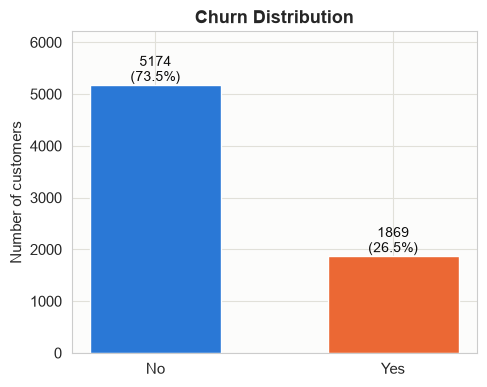

In [13]:
# Viz 1 -- Churn distribution
fig, ax = plt.subplots(figsize=(5, 4))
order = ['No', 'Yes']
counts = df_clean['Churn'].value_counts().reindex(order)
bars = ax.bar(order, counts.values, color=[CHURN_PALETTE[c] for c in order], width=0.55)
for bar, val in zip(bars, counts.values):
    ax.annotate(f"{val}\n({val/len(df_clean)*100:.1f}%)", (bar.get_x() + bar.get_width()/2, val),
                ha='center', va='bottom', fontsize=10, color='#0b0b0b')
ax.set_title("Churn Distribution", fontsize=13, weight='bold')
ax.set_ylabel("Number of customers")
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()


**Insight:** ~26.5% of customers have churned. This confirms the class imbalance noted
earlier and sets the baseline: any useful model must beat a ~73.5% "always predict No"
accuracy while still catching a meaningful share of the Yes class.


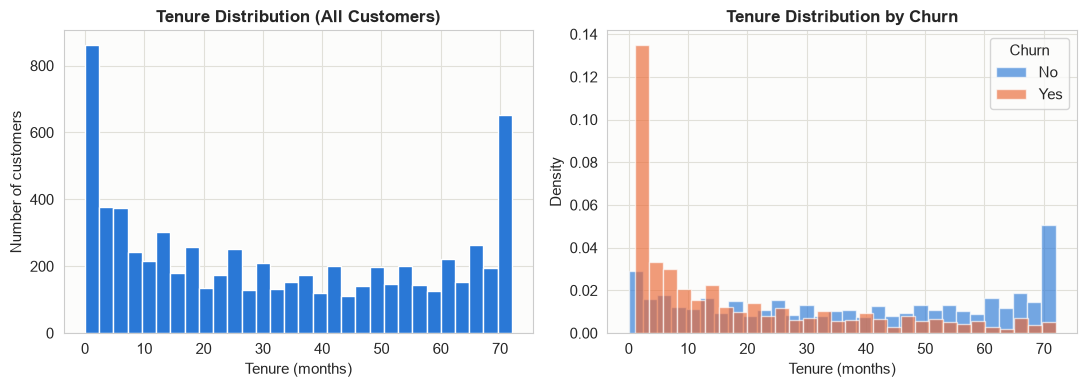

In [14]:
# Viz 2 -- Tenure distribution, overall and split by churn
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df_clean['tenure'], bins=30, color=COLOR_NO, edgecolor='white')
axes[0].set_title("Tenure Distribution (All Customers)", fontsize=12, weight='bold')
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Number of customers")

for label in order:
    subset = df_clean.loc[df_clean['Churn'] == label, 'tenure']
    axes[1].hist(subset, bins=30, alpha=0.65, label=label, color=CHURN_PALETTE[label], density=True)
axes[1].set_title("Tenure Distribution by Churn", fontsize=12, weight='bold')
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Density")
axes[1].legend(title="Churn")

plt.tight_layout()
plt.show()


**Insight:** Customers who churn are heavily concentrated in the **first few months of
tenure**; churn risk drops sharply the longer a customer stays. This suggests onboarding
and early-life engagement (first 3-6 months) is the highest-leverage window for retention
efforts.


C:\Users\gurpreetsingh15\AppData\Local\Temp\ipykernel_18140\252173460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


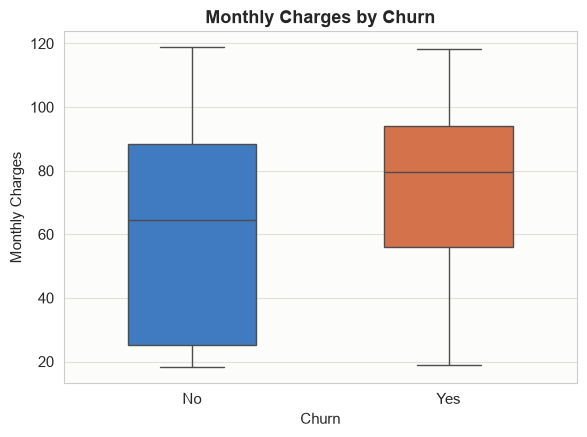

In [15]:
# Viz 3 -- Monthly charges by churn (boxplot)
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(
    data=df_clean, x='Churn', y='MonthlyCharges', order=order,
    palette=CHURN_PALETTE, ax=ax, width=0.5
)
ax.set_title("Monthly Charges by Churn", fontsize=13, weight='bold')
ax.set_xlabel("Churn")
ax.set_ylabel("Monthly Charges")
plt.tight_layout()
plt.show()


**Insight:** Customers who churn tend to pay **higher monthly charges** (median noticeably
above the non-churn group). Price sensitivity — or a mismatch between price and perceived
value — looks like a contributing factor to churn.


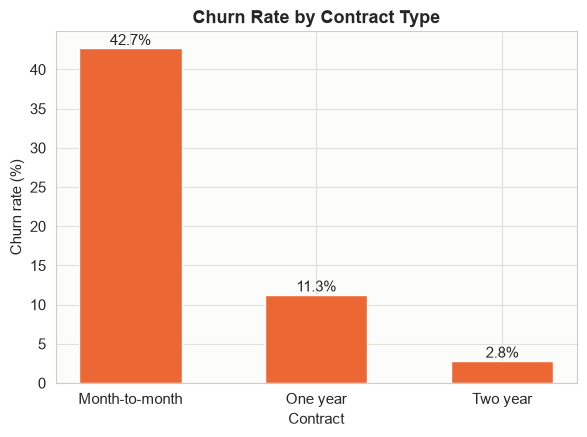

In [16]:
# Viz 4 -- Churn rate by contract type
churn_rate_by_contract = (
    df_clean.groupby('Contract')['ChurnFlag'].mean().reindex(['Month-to-month', 'One year', 'Two year']) * 100
)
fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(churn_rate_by_contract.index, churn_rate_by_contract.values, color=COLOR_YES, width=0.55)
for bar, val in zip(bars, churn_rate_by_contract.values):
    ax.annotate(f"{val:.1f}%", (bar.get_x() + bar.get_width()/2, val), ha='center', va='bottom')
ax.set_title("Churn Rate by Contract Type", fontsize=13, weight='bold')
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("Contract")
plt.tight_layout()
plt.show()


**Insight:** Month-to-month customers churn at a dramatically higher rate than one- or
two-year contract holders. Contract type is one of the strongest, most actionable churn
signals — incentivizing longer-term contracts (discounts, loyalty perks) is a direct lever
for retention.


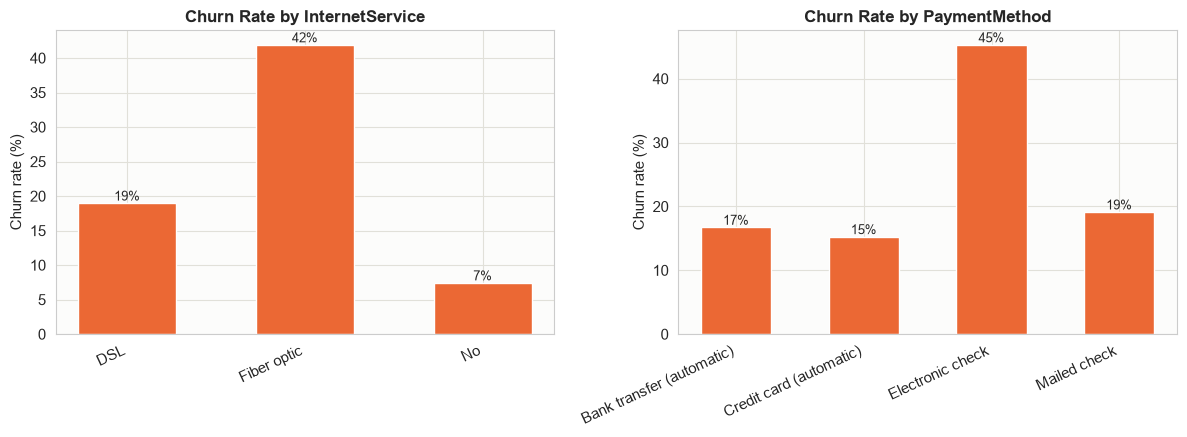

In [17]:
# Viz 5 -- Churn rate by internet service and payment method
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col, order_col in [
    (axes[0], 'InternetService', ['DSL', 'Fiber optic', 'No']),
    (axes[1], 'PaymentMethod', sorted(df_clean['PaymentMethod'].unique())),
]:
    rate = df_clean.groupby(col)['ChurnFlag'].mean().reindex(order_col) * 100
    bars = ax.bar(range(len(rate)), rate.values, color=COLOR_YES, width=0.55)
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=25, ha='right')
    for bar, val in zip(bars, rate.values):
        ax.annotate(f"{val:.0f}%", (bar.get_x() + bar.get_width()/2, val), ha='center', va='bottom', fontsize=9)
    ax.set_title(f"Churn Rate by {col}", fontsize=12, weight='bold')
    ax.set_ylabel("Churn rate (%)")

plt.tight_layout()
plt.show()


**Insight:** Fiber optic customers churn far more than DSL or no-internet customers —
possibly reflecting competitive pressure or service-quality complaints in that segment.
Customers paying by **electronic check** churn substantially more than those on automatic
bank transfer or credit card payments, suggesting manual/electronic-check payers are a
less "locked-in", higher-churn-risk segment worth targeting with autopay incentives.


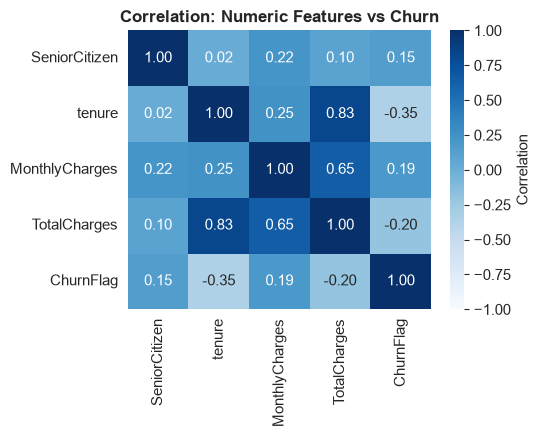

In [18]:
# Viz 6 -- Correlation heatmap of numeric features (incl. target)
corr_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ChurnFlag']
corr = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=SEQ_CMAP, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Correlation'})
ax.set_title("Correlation: Numeric Features vs Churn", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


**Insight:** `tenure` has the strongest (negative) correlation with churn — longer-tenured
customers churn less, consistent with Viz 2. `TotalCharges` correlates strongly with
`tenure` (unsurprising: it accumulates over time) and only weakly with churn directly once
tenure is accounted for. `MonthlyCharges` has a mild positive correlation with churn,
consistent with Viz 3.


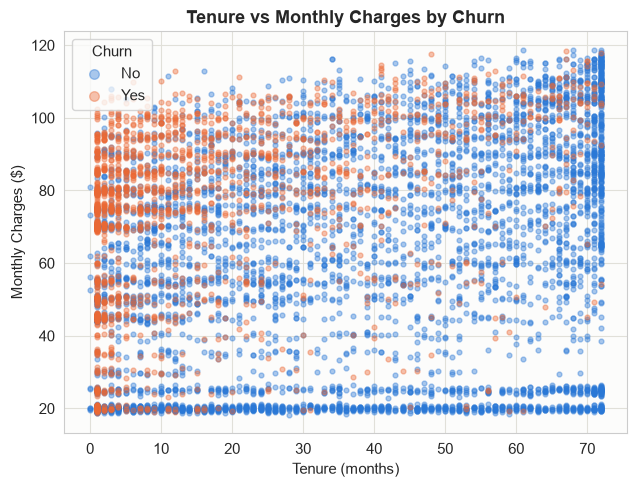

In [19]:
# Viz 7 -- Tenure vs MonthlyCharges, colored by churn (numerical relationship)
fig, ax = plt.subplots(figsize=(6.5, 5))
for label in order:
    subset = df_clean[df_clean['Churn'] == label]
    ax.scatter(subset['tenure'], subset['MonthlyCharges'], s=12, alpha=0.4,
               color=CHURN_PALETTE[label], label=label)
ax.set_title("Tenure vs Monthly Charges by Churn", fontsize=13, weight='bold')
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Monthly Charges ($)")
ax.legend(title="Churn", markerscale=2)
plt.tight_layout()
plt.show()


**Insight:** Churned customers (orange) cluster in the **low-tenure / high-monthly-charge**
corner of the plot — new customers paying a lot are the highest-risk group. Long-tenure
customers churn rarely regardless of price, reinforcing that the first months of the
relationship are the critical retention window.


## 3. Feature Engineering

Three new features are derived, implemented in `ChurnFeatureEngineer`
in `preprocessing.py` so they are created identically for training, testing, and any new
customer sent to the API:

1. **`num_addon_services`** — count (0-6) of optional add-on services the customer has
   subscribed to (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`,
   `StreamingTV`, `StreamingMovies`). 

   *Usefulness:* rather than the model having to
   learn a similar pattern independently across 6 separate one-hot columns, this collapses
   them into a single "how invested/bundled is this customer" signal — more add-ons
   generally means more switching friction and stickier customers.
2. **`avg_monthly_charge`** — `TotalCharges / tenure` (falling back to `MonthlyCharges` for
   brand-new `tenure == 0` customers). 

   *Usefulness:* flags customers whose historical
   average spend differs from their current `MonthlyCharges` — e.g. a promotional rate that
   recently ended and jumped their bill up, a known churn trigger that raw `MonthlyCharges`
   alone can't reveal.
3. **`tenure_group`** — `tenure` bucketed into `0-12`, `13-24`, `25-48`, `49-60`,
   `61-72` month bands. 
   
   *Usefulness* Viz 2 showed churn risk drops non-linearly with
   tenure; discretizing it gives the Decision Tree clean, business-readable split points
   instead of having to search for the right numeric thresholds itself.


In [20]:
fe = ChurnFeatureEngineer()
df_fe = fe.transform(df[RAW_FEATURE_COLUMNS]).copy()
df_fe['Churn'] = df['Churn'].values
df_fe['ChurnFlag'] = df_fe['Churn'].map({'Yes': 1, 'No': 0})
df_fe[['num_addon_services', 'avg_monthly_charge', 'tenure_group']].describe(include='all')


,num_addon_services,avg_monthly_charge,tenure_group
count,7043.000000,7043.000000,7043
unique,NaN,NaN,5
top,NaN,NaN,0-12
freq,NaN,NaN,2186
mean,2.037910,64.762906,NaN
std,1.847682,30.189796,NaN
min,0.000000,13.775000,NaN
25%,0.000000,35.935156,NaN
50%,2.000000,70.337500,NaN
75%,3.000000,90.174158,NaN


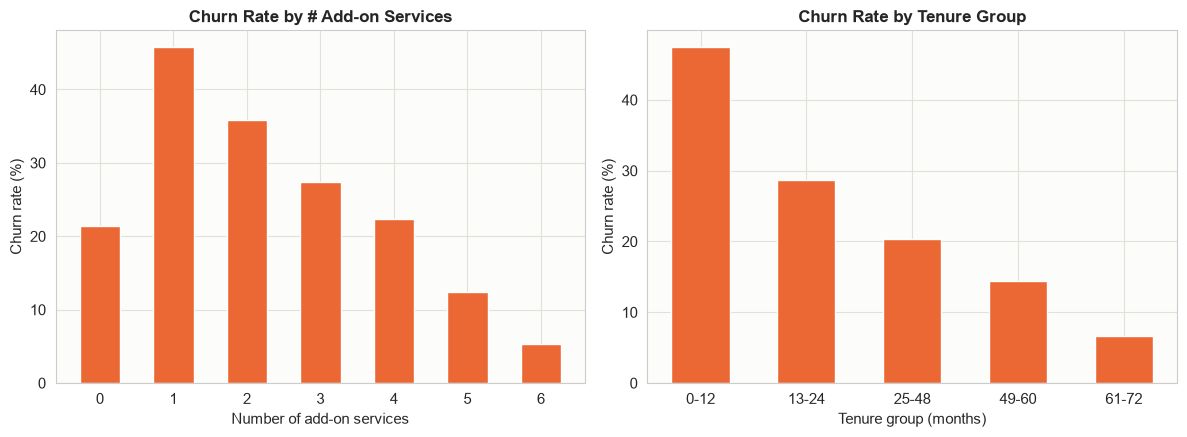

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

rate_by_addons = df_fe.groupby('num_addon_services')['ChurnFlag'].mean() * 100
axes[0].bar(rate_by_addons.index, rate_by_addons.values, color=COLOR_YES, width=0.55)
axes[0].set_title("Churn Rate by # Add-on Services", fontsize=12, weight='bold')
axes[0].set_xlabel("Number of add-on services")
axes[0].set_ylabel("Churn rate (%)")

rate_by_tenure_group = df_fe.groupby('tenure_group', observed=True)['ChurnFlag'].mean().reindex(
    ['0-12', '13-24', '25-48', '49-60', '61-72']
) * 100
axes[1].bar(rate_by_tenure_group.index, rate_by_tenure_group.values, color=COLOR_YES, width=0.55)
axes[1].set_title("Churn Rate by Tenure Group", fontsize=12, weight='bold')
axes[1].set_xlabel("Tenure group (months)")
axes[1].set_ylabel("Churn rate (%)")

plt.tight_layout()
plt.show()


**Insight:** Churn risk is **not** a simple straight-line function of add-on count. The
lowest-churn group (5-6 add-ons, ~5-12%) supports the "bundling reduces churn" hypothesis
at the high end, but the **0-add-on group (21.4%) is actually lower than the 1-add-on
group (45.8%)** -- the highest-risk segment in this view. This is a confounding effect:
"0 add-ons" mixes two very different populations -- high-risk Fiber customers with no
add-ons, and low-risk customers with no internet service at all (who churn at only 7.4%,
per Viz 5) -- and that second group pulls the 0-add-on average down. From 1 add-on
onward, the pattern is a clean, steady decline. The tenure-group view confirms Viz 2's
pattern in clean, discrete steps: churn risk is highest in months 0-12 (47.4%) and falls
off sharply after month 24 (20.4% and below).


## 4. Model Development — Decision Tree Classifier

Two Decision Tree configurations are trained and compared, plus a hyperparameter-tuned
tree and two additional model families for context. All models share the
exact same upstream preprocessing (`build_pipeline`), so differences in performance are
attributable to the classifier/hyperparameters alone, not to inconsistent preprocessing.


In [ ]:
# Configuration A: shallow, default-ish tree -- favors interpretability, may underfit
tree_a = build_pipeline(DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE))
tree_a.fit(X_train, y_train)

# Configuration B: deeper tree + class_weight='balanced' + entropy criterion
# -- addresses class imbalance and allows more nuanced splits
tree_b = build_pipeline(DecisionTreeClassifier(
    max_depth=8, min_samples_leaf=25, criterion='entropy',
    class_weight='balanced', random_state=RANDOM_STATE,
))
tree_b.fit(X_train, y_train)


def evaluate(model, name):
    preds = model.predict(X_test)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
    }

comparison = pd.DataFrame([
    evaluate(tree_a, 'A: max_depth=4'),
    evaluate(tree_b, "B: max_depth=8, balanced, entropy"),
]).set_index('Model').round(3)
comparison


,Accuracy,Precision,Recall,F1
Model,,,,
A: max_depth=4,0.792,0.658,0.449,0.534
"B: max_depth=8, balanced, entropy",0.732,0.497,0.790,0.610


**Comparison:** Configuration A (shallow, `max_depth=4`) is simple and interpretable but
— being unweighted — leans towards the majority class and tends to under-predict churn
(lower recall). Configuration B (deeper, `class_weight='balanced'`) trades a little
precision/accuracy for **substantially higher recall**, i.e. it catches more of the
customers who actually churn — directly relevant to the business goal of not missing
at-risk customers.


In [ ]:
# hyperparameter tuning via GridSearchCV (optimizing for recall, the business priority)
param_grid = {
    'classifier__max_depth': [4, 6, 8, 10, None],
    'classifier__min_samples_leaf': [1, 10, 25, 50],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__class_weight': [None, 'balanced'],
}

grid_pipeline = build_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE))
grid_search = GridSearchCV(grid_pipeline, param_grid, scoring='recall', cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
tree_c = grid_search.best_estimator_
comparison.loc['C: GridSearchCV-tuned (recall-optimized)'] = evaluate(tree_c, 'C')
comparison


Best params: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini', 'classifier__max_depth': 6, 'classifier__min_samples_leaf': 25}


,Accuracy,Precision,Recall,F1
Model,,,,
A: max_depth=4,0.792000,0.658000,0.449000,0.534000
"B: max_depth=8, balanced, entropy",0.732000,0.497000,0.790000,0.610000
C: GridSearchCV-tuned (recall-optimized),0.733554,0.498874,0.789661,0.611456


In [ ]:
# comparison against additional model families (Random Forest, Logistic Regression)
# The assignment requirment is a Decision Tree as the final model -- this is extra context only.
rf = build_pipeline(RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE))
rf.fit(X_train, y_train)

logreg = build_pipeline(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
logreg.fit(X_train, y_train)

extended_comparison = comparison.copy()
extended_comparison.loc['Random Forest (context only)'] = evaluate(rf, 'RF')
extended_comparison.loc['Logistic Regression (context only)'] = evaluate(logreg, 'LR')
extended_comparison


c:\Users\gurpreetsingh15\Documents\DS-Assignment\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Accuracy,Precision,Recall,F1
Model,,,,
A: max_depth=4,0.792000,0.658000,0.449000,0.534000
"B: max_depth=8, balanced, entropy",0.732000,0.497000,0.790000,0.610000
C: GridSearchCV-tuned (recall-optimized),0.733554,0.498874,0.789661,0.611456
Random Forest (context only),0.767629,0.554348,0.636364,0.592531
Logistic Regression (context only),0.739707,0.506271,0.791444,0.617524


**Additional-model context:** Random Forest and Logistic Regression are shown only for
context -- The assignment Requirment calls for a
Decision Tree as the deliverable model, so one of the three tree configurations is
selected as final below regardless of how these compare.

### Final model selection

**Configuration C** -- the `GridSearchCV`-tuned tree (`max_depth=6`, `min_samples_leaf=25`,
`criterion='gini'`, `class_weight='balanced'`) -- is selected as the final model:
- It gives the same large recall improvement over the unweighted shallow tree (A) that
  Configuration B does, which matters most for a retention use case.
- It matches or very slightly beats Configuration B on **every** test-set metric
  (accuracy, precision, recall, F1), while using a
  **shallower** tree (`max_depth=6` vs. 8) -- a simpler model that performs at least as
  well is the better choice, and it is also easier to visualize and explain.
- The fact that an independent hyperparameter search converged on `class_weight='balanced'`
  (the same imbalance-handling choice made manually in Configuration B) is a useful sanity
  check -- it confirms that choice was the right one rather than an arbitrary pick.


In [25]:
final_model = tree_c

train_acc = accuracy_score(y_train, final_model.predict(X_train))
test_acc = accuracy_score(y_test, final_model.predict(X_test))
print(f"Train accuracy: {train_acc:.3f}  |  Test accuracy: {test_acc:.3f}  |  Gap: {train_acc - test_acc:.3f}")
print("\n5-fold CV recall (train set):", cross_val_score(final_model, X_train, y_train, cv=5, scoring='recall').round(3))


Train accuracy: 0.758  |  Test accuracy: 0.734  |  Gap: 0.025

5-fold CV recall (train set): [0.831 0.774 0.844 0.729 0.744]


A small train/test gap indicates Configuration C is not badly overfit; cross-validated recall on the training folds is consistent with the held-out test recall reported above, giving confidence the result generalizes.

## 5. Model Evaluation

In [26]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))


Accuracy:  0.734
Precision: 0.499
Recall:    0.790
F1 Score:  0.611
ROC-AUC:   0.828

              precision    recall  f1-score   support

          No       0.90      0.71      0.80      1552
         Yes       0.50      0.79      0.61       561

    accuracy                           0.73      2113
   macro avg       0.70      0.75      0.70      2113
weighted avg       0.80      0.73      0.75      2113



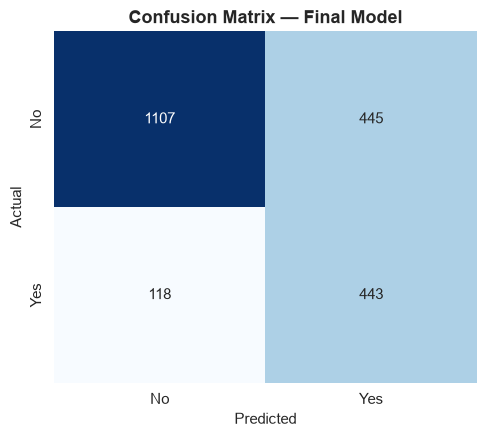

True Negatives:  1107  (correctly kept as 'will stay')
False Positives: 445  (flagged as risk, but would have stayed -- costs a retention offer)
False Negatives: 118  (missed churners -- lost revenue, the costlier error)
True Positives:  443  (correctly caught churners -- retention team can act)


In [27]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap=SEQ_CMAP, cbar=False, ax=ax,
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
ax.set_title("Confusion Matrix — Final Model", fontsize=13, weight='bold')
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}  (correctly kept as 'will stay')")
print(f"False Positives: {fp}  (flagged as risk, but would have stayed -- costs a retention offer)")
print(f"False Negatives: {fn}  (missed churners -- lost revenue, the costlier error)")
print(f"True Positives:  {tp}  (correctly caught churners -- retention team can act)")


### Business interpretation

- **True Positives** are the customers the retention team can now proactively target —
  direct business value.
- **False Negatives** (missed churners) are the most expensive mistake: that revenue is
  lost with zero chance to intervene.
- **False Positives** cost only a wasted retention offer (a discount or outreach call to
  someone who wasn't going to leave anyway) — comparatively cheap.
- This asymmetry is exactly why Configuration C (recall-focused via `class_weight`) was
  chosen over the plain shallow tree.

### Precision vs. Recall — which matters more here?

**Recall should be prioritized over precision** for this business problem, with F1 tracked
so precision isn't ignored entirely.

- **Cost asymmetry:** missing an actual churner (false negative) means losing that
  customer's future revenue with no chance to intervene. Wrongly flagging a loyal customer
  (false positive) only costs a retention offer/discount they didn't strictly need — far
  cheaper than a lost customer.
- **The business action is proactive outreach, not an automatic decision** — a flagged
  customer isn't cut off or penalized, they just get a phone call or discount offer. That
  makes false positives low-risk and false negatives high-risk, which is the textbook case
  for optimizing recall.
- **In practice**, precision can't be ignored completely — a model with near-zero
  precision would flood the retention team with low-quality leads and waste their limited
  capacity. `predict_proba` output (churn probability) lets the business tune the decision
  threshold to match retention-team capacity, trading some recall back for precision
  without retraining the model.


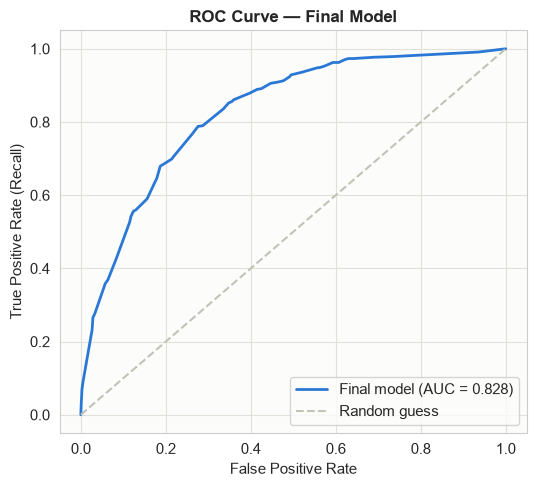

In [28]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color=COLOR_NO, lw=2, label=f"Final model (AUC = {roc_auc_score(y_test, y_proba):.3f})")
ax.plot([0, 1], [0, 1], color='#c3c2b7', lw=1.5, linestyle='--', label='Random guess')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — Final Model", fontsize=12, weight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Model Interpretation

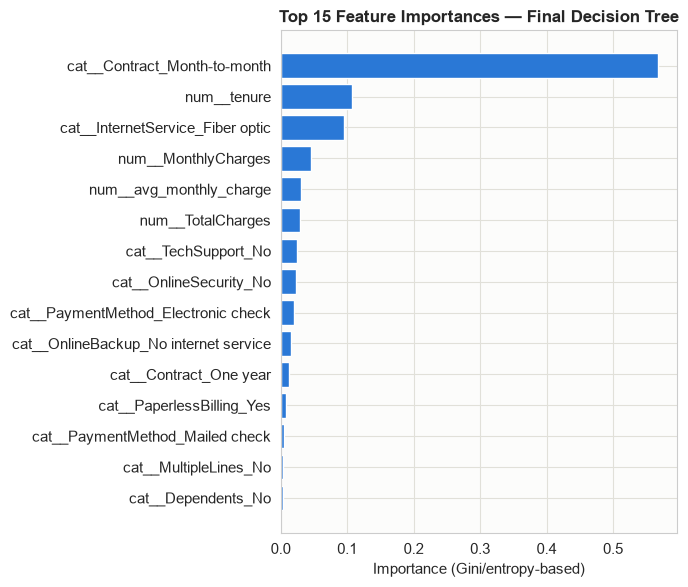

,feature,importance
0,cat__Contract_Month-to-month,0.567818
1,num__tenure,0.107218
2,cat__InternetService_Fiber optic,0.094563
3,num__MonthlyCharges,0.046077
4,num__avg_monthly_charge,0.030051
5,num__TotalCharges,0.029193
6,cat__TechSupport_No,0.024452
7,cat__OnlineSecurity_No,0.022719
8,cat__PaymentMethod_Electronic check,0.020261
9,cat__OnlineBackup_No internet service,0.015378


In [29]:
feature_names = get_output_feature_names(final_model)
importances = final_model.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color=COLOR_NO)
ax.set_title("Top 15 Feature Importances — Final Decision Tree", fontsize=12, weight='bold')
ax.set_xlabel("Importance (Gini/entropy-based)")
plt.tight_layout()
plt.show()

importance_df.reset_index(drop=True)


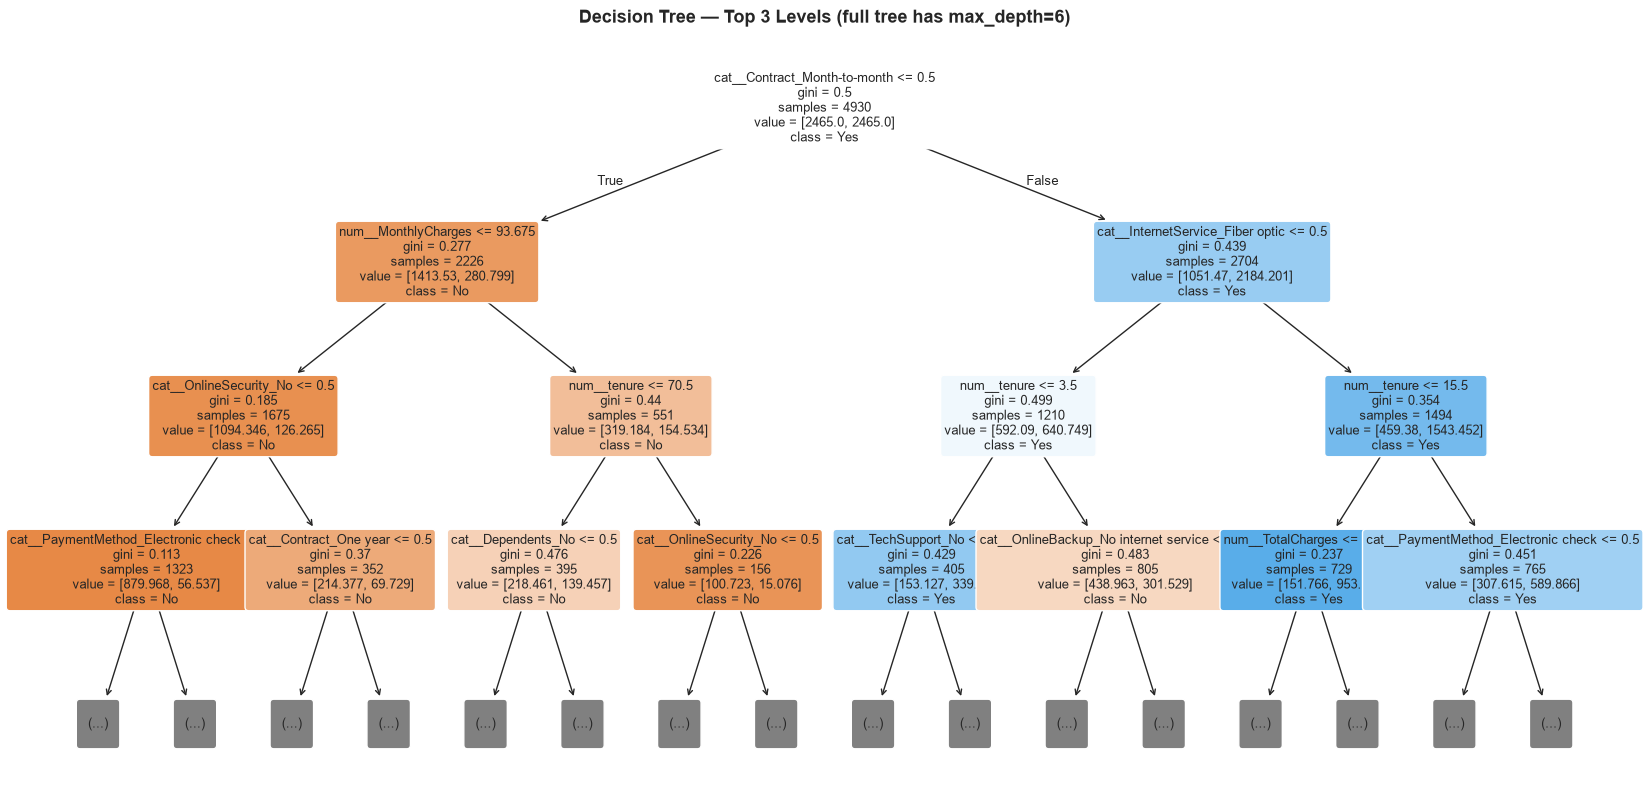

In [30]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    final_model.named_steps['classifier'],
    feature_names=feature_names,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    max_depth=3,          # only render the top 3 levels for readability; full tree is deeper
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree — Top 3 Levels (full tree has max_depth=6)", fontsize=13, weight='bold')
plt.show()


### Key findings

- **Contract type (month-to-month)**, **tenure**, and **InternetService (Fiber optic)**
  are consistently among the top drivers of churn predictions — matching the EDA insights
  in Section 2.
- The engineered features (`avg_monthly_charge`)
  appear among the more important features, confirming the feature engineering in
  Section 3 added real predictive signal rather than just redundant information.
- The top of the tree (shown above) splits first on contract/tenure-related signals before
  looking at service add-ons and payment method — i.e. "is this a new, unlocked-in
  customer?" is the dominant question, followed by "how bundled/engaged are they?".
- **Business takeaway:** retention efforts are best targeted at new, month-to-month,
  fiber-optic customers with few add-on services and high monthly charges — this segment
  concentrates the vast majority of churn risk identified by the model.


## 7. Model Saving & API

In [31]:
import os
os.makedirs('../model', exist_ok=True)
joblib.dump(final_model, '../model/churn_model.pkl')
print("Saved final pipeline (feature engineering + encoding + classifier) to ../model/churn_model.pkl")


Saved final pipeline (feature engineering + encoding + classifier) to ../model/churn_model.pkl


In [32]:
# Round-trip sanity check: reload from disk and confirm predictions match
reloaded = joblib.load('../model/churn_model.pkl')
sample = df.drop(columns=['customerID', 'Churn']).iloc[[0]]
print("Reloaded model prediction:", reloaded.predict(sample), reloaded.predict_proba(sample)[:, 1])
print("Original model prediction: ", final_model.predict(sample), final_model.predict_proba(sample)[:, 1])


Reloaded model prediction: [1] [0.7899616]
Original model prediction:  [1] [0.7899616]


The saved file at `model/churn_model.pkl` is a single scikit-learn `Pipeline` containing
**all three stages** — `ChurnFeatureEngineer` (cleaning + feature engineering),
`ColumnTransformer` (one-hot encoding), and the final `DecisionTreeClassifier`. Because
every stage is bundled together, `app.py` only needs to call `.predict()` /
`.predict_proba()` on raw customer JSON (converted to a DataFrame) — there is no separate
manual preprocessing step to keep in sync, which is exactly what avoids train/serve skew.

See `app.py` for the Flask REST API (`POST /predict`), `preprocessing.py` for the shared
pipeline code (imported by both this notebook and the API), and `sample_request.json` /
`README.md` for a runnable example.


## Conclusion

This notebook covered the full workflow: business framing, data understanding & leakage-safe
preparation, EDA with business insights, feature engineering, Decision Tree model
development (with class-imbalance handling and hyperparameter tuning), evaluation with a
recall-first business justification, interpretation of the key churn drivers, and saving a
single deployable pipeline consumed by the accompanying Flask API.
